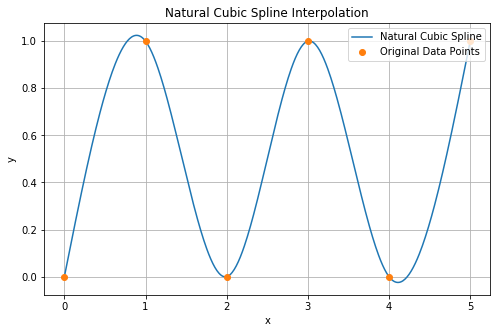

Step sizes h:
[1. 1. 1. 1. 1.]

Second derivatives M:
[ 0.         -4.36363636  5.45454545 -5.45454545  4.36363636  0.        ]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)


def natural_cubic_spline(x, y):
    n = len(x)

    if n < 3:
        raise ValueError("Need at least 3 data points for a cubic spline.")
    if np.any(np.diff(x) <= 0):
        raise ValueError("x values must be strictly increasing.")

    h = np.diff(x)

    A = np.zeros(n - 2) 
    B = np.zeros(n - 2)  
    C = np.zeros(n - 2)  
    D = np.zeros(n - 2)  

    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6 * (
            (y[i + 1] - y[i]) / h[i]
            - (y[i] - y[i - 1]) / h[i - 1]
        )

    for i in range(1, n - 2):
        factor = A[i] / B[i - 1]
        B[i] = B[i] - factor * C[i - 1]
        D[i] = D[i] - factor * D[i - 1]

    M_inner = np.zeros(n - 2)
    M_inner[-1] = D[-1] / B[-1]

    for i in range(n - 4, -1, -1):
        M_inner[i] = (D[i] - C[i] * M_inner[i + 1]) / B[i]

    M = np.zeros(n)
    M[1:n - 1] = M_inner

    return h, M


def evaluate_spline(x, y, h, M, x_eval):
    x_eval = np.array(x_eval, dtype=float)
    y_eval = np.zeros_like(x_eval)

    for j, xe in enumerate(x_eval):
        if xe < x[0] or xe > x[-1]:
            raise ValueError("Evaluation point is outside the interpolation range.")

        i = np.searchsorted(x, xe) - 1
        if i == len(x) - 1:
            i -= 1
        if i < 0:
            i = 0

        hi = h[i]
        xi, xi1 = x[i], x[i + 1]
        yi, yi1 = y[i], y[i + 1]
        Mi, Mi1 = M[i], M[i + 1]

        term1 = Mi * (xi1 - xe) ** 3 / (6 * hi)
        term2 = Mi1 * (xe - xi) ** 3 / (6 * hi)
        term3 = (yi - Mi * hi**2 / 6) * (xi1 - xe) / hi
        term4 = (yi1 - Mi1 * hi**2 / 6) * (xe - xi) / hi

        y_eval[j] = term1 + term2 + term3 + term4

    return y_eval


h, M = natural_cubic_spline(x, y)

x_interp = np.linspace(x[0], x[-1], 400)
y_interp = evaluate_spline(x, y, h, M, x_interp)

plt.figure(figsize=(8, 5))
plt.plot(x_interp, y_interp, label="Natural Cubic Spline")
plt.plot(x, y, "o", label="Original Data Points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Natural Cubic Spline Interpolation")
plt.legend()
plt.grid(True)
plt.show()

print("Step sizes h:")
print(h)

print("\nSecond derivatives M:")
print(M)